<a href="https://colab.research.google.com/github/MayurBhagwatkar/ColabCode1/blob/main/AlexNet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Flatten,Dense,Activation,Dropout,BatchNormalization
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

In [4]:
(X_train,y_train),(X_test,y_test)=cifar10.load_data()
# Normalise Pixel Values
X_train=X_train.astype('float32')/255
X_test=X_test.astype('float32')/255

# One-Hot encoding the Labels
y_train=to_categorical(y_train,10)
y_test=to_categorical(y_test,10)

In [5]:
model=Sequential()
# Layer1
model.add(Conv2D(96,kernel_size=(3,3),strides=(1,1), input_shape=(32,32,3),padding='same'))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2),strides=(2,2)))
model.add(BatchNormalization())


# Layer2
model.add(Conv2D(256,kernel_size=(3,3),strides=(1,1), input_shape=(32,32,3),padding='same'))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2),strides=(2,2)))
model.add(BatchNormalization())

# Layer3
model.add(Conv2D(384,kernel_size=(3,3),strides=(1,1), input_shape=(32,32,3),padding='same'))
model.add(Activation('relu'))


# Layer4
model.add(Conv2D(384,kernel_size=(3,3),strides=(1,1), input_shape=(32,32,3),padding='same'))
model.add(Activation('relu'))


# Layer5
model.add(Conv2D(256,kernel_size=(3,3),strides=(1,1), input_shape=(32,32,3),padding='same'))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2),strides=(2,2)))
model.add(BatchNormalization())

# Flattening
model.add(Flatten())

# Fully Connected Layer1
model.add(Dense(1024))
model.add(Activation('relu'))
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(10))
model.add(Activation('softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
model.compile(loss='categorical_crossentropy',optimizer='adam',metrics=['accuracy'])

In [7]:
history=model.fit(X_train,y_train,batch_size=128,epochs=15,validation_split=0.2,verbose=1)

Epoch 1/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 38s 85ms/step - accuracy: 0.4340 - loss: 1.6270 - val_accuracy: 0.0983 - val_loss: 11.5885
Epoch 2/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 52ms/step - accuracy: 0.6107 - loss: 1.1087 - val_accuracy: 0.3759 - val_loss: 2.6400
Epoch 3/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 51ms/step - accuracy: 0.6953 - loss: 0.8740 - val_accuracy: 0.7050 - val_loss: 0.8587
Epoch 4/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 49ms/step - accuracy: 0.7451 - loss: 0.7293 - val_accuracy: 0.6340 - val_loss: 1.1679
Epoch 5/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 51ms/step - accuracy: 0.7894 - loss: 0.6076 - val_accuracy: 0.7377 - val_loss: 0.8086
Epoch 6/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 50ms/step - accuracy: 0.8280 - loss: 0.4996 - val_accuracy: 0.7608 - val_loss: 0.7246
Epoch 7/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 51ms/step - accuracy: 0.8546 - loss: 0.4163 - val_accuracy: 0.7437 - val_loss: 0.8680
Epoch 8/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 51ms/step - accuracy: 0.8795 - loss: 0.3463 -

In [8]:
test_loss,test_acc=model.evaluate(X_test,y_test)
print(test_loss,test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7968 - loss: 0.9477
0.9476616382598877 0.7968000173568726


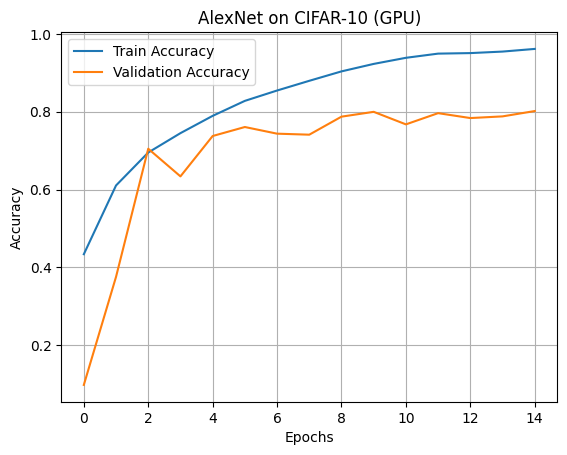

In [9]:
plt.plot(history.history['accuracy'],label='Train Accuracy')
plt.plot(history.history['val_accuracy'],label='Validation Accuracy')
plt.title('AlexNet on CIFAR-10 (GPU)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()